In [1]:
# 1. Trở về gốc và dọn dẹp thư mục cũ
%cd /content/
!rm -rf image-preprocessing-classification

# 2. Tải source code (chỉ định chính xác nhánh develop)
!git clone -b develop https://github.com/AIVIETNAM-AIO-Dewey/image-preprocessing-classification.git

# 3. Di chuyển vào thư mục dự án
%cd /content/image-preprocessing-classification

# 4. Cài đặt thư viện
!pip install -r requirements.txt

# 5. Tải data và cắt patch (sẽ mất vài phút)
!python src/data/download_data.py
!python src/data/process_patches.py

/content
Cloning into 'image-preprocessing-classification'...
remote: Enumerating objects: 241, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 241 (delta 20), reused 23 (delta 16), pack-reused 192 (from 1)
Receiving objects: 100% (241/241), 905.21 KiB | 11.91 MiB/s, done.
Resolving deltas: 100% (100/100), done.
/content/image-preprocessing-classification
Downloading...
From (original): https://drive.google.com/uc?id=1oMDFwlGwObPg0kmyFVGVoYEMtc8ubOWT
From (redirected): https://drive.google.com/uc?id=1oMDFwlGwObPg0kmyFVGVoYEMtc8ubOWT&confirm=t&uuid=5ab80b09-19fb-4ddf-b043-aa5f6003e20e
To: /content/image-preprocessing-classification/data/raw/rdd2022_india.zip
100% 527M/527M [00:06<00:00, 77.4MB/s]
Extracting dataset...
Extraction completed successfully!
Cleaned up the zip file.
Found dataset at: data/raw/India/train
Total xml annotation files: 7706
Processing train split (5394 images)...
100% 5394/5394 [00:18<00:00, 292.3

/content/image-preprocessing-classification

⚙️ 1/2. ĐANG CHẠY PIPELINE 3 (SIÊU THAM SỐ GỐC)...

--- Offline Preprocessing: pipeline3_grayscale_bilateral ---
Reorganizing raw cropped patches: moving train/val/test to data/processed/cropped
Reading raw cropped images from: data/processed/cropped
Saving preprocessed images to: data/processed/grayscale_bilateral
Processing split 'train', class 'D00' (1102 images)...
100% 1102/1102 [00:01<00:00, 570.57it/s]
Processing split 'train', class 'D20' (1403 images)...
100% 1403/1403 [00:08<00:00, 170.03it/s]
Processing split 'train', class 'D40' (2278 images)...
100% 2278/2278 [00:03<00:00, 597.15it/s]
Processing split 'train', class 'Normal' (7900 images)...
100% 7900/7900 [00:15<00:00, 509.63it/s]
Processing split 'val', class 'D00' (225 images)...
100% 225/225 [00:00<00:00, 550.53it/s]
Processing split 'val', class 'D20' (300 images)...
100% 300/300 [00:01<00:00, 181.36it/s]
Processing split 'val', class 'D40' (465 images)...
100% 465/465 [00:

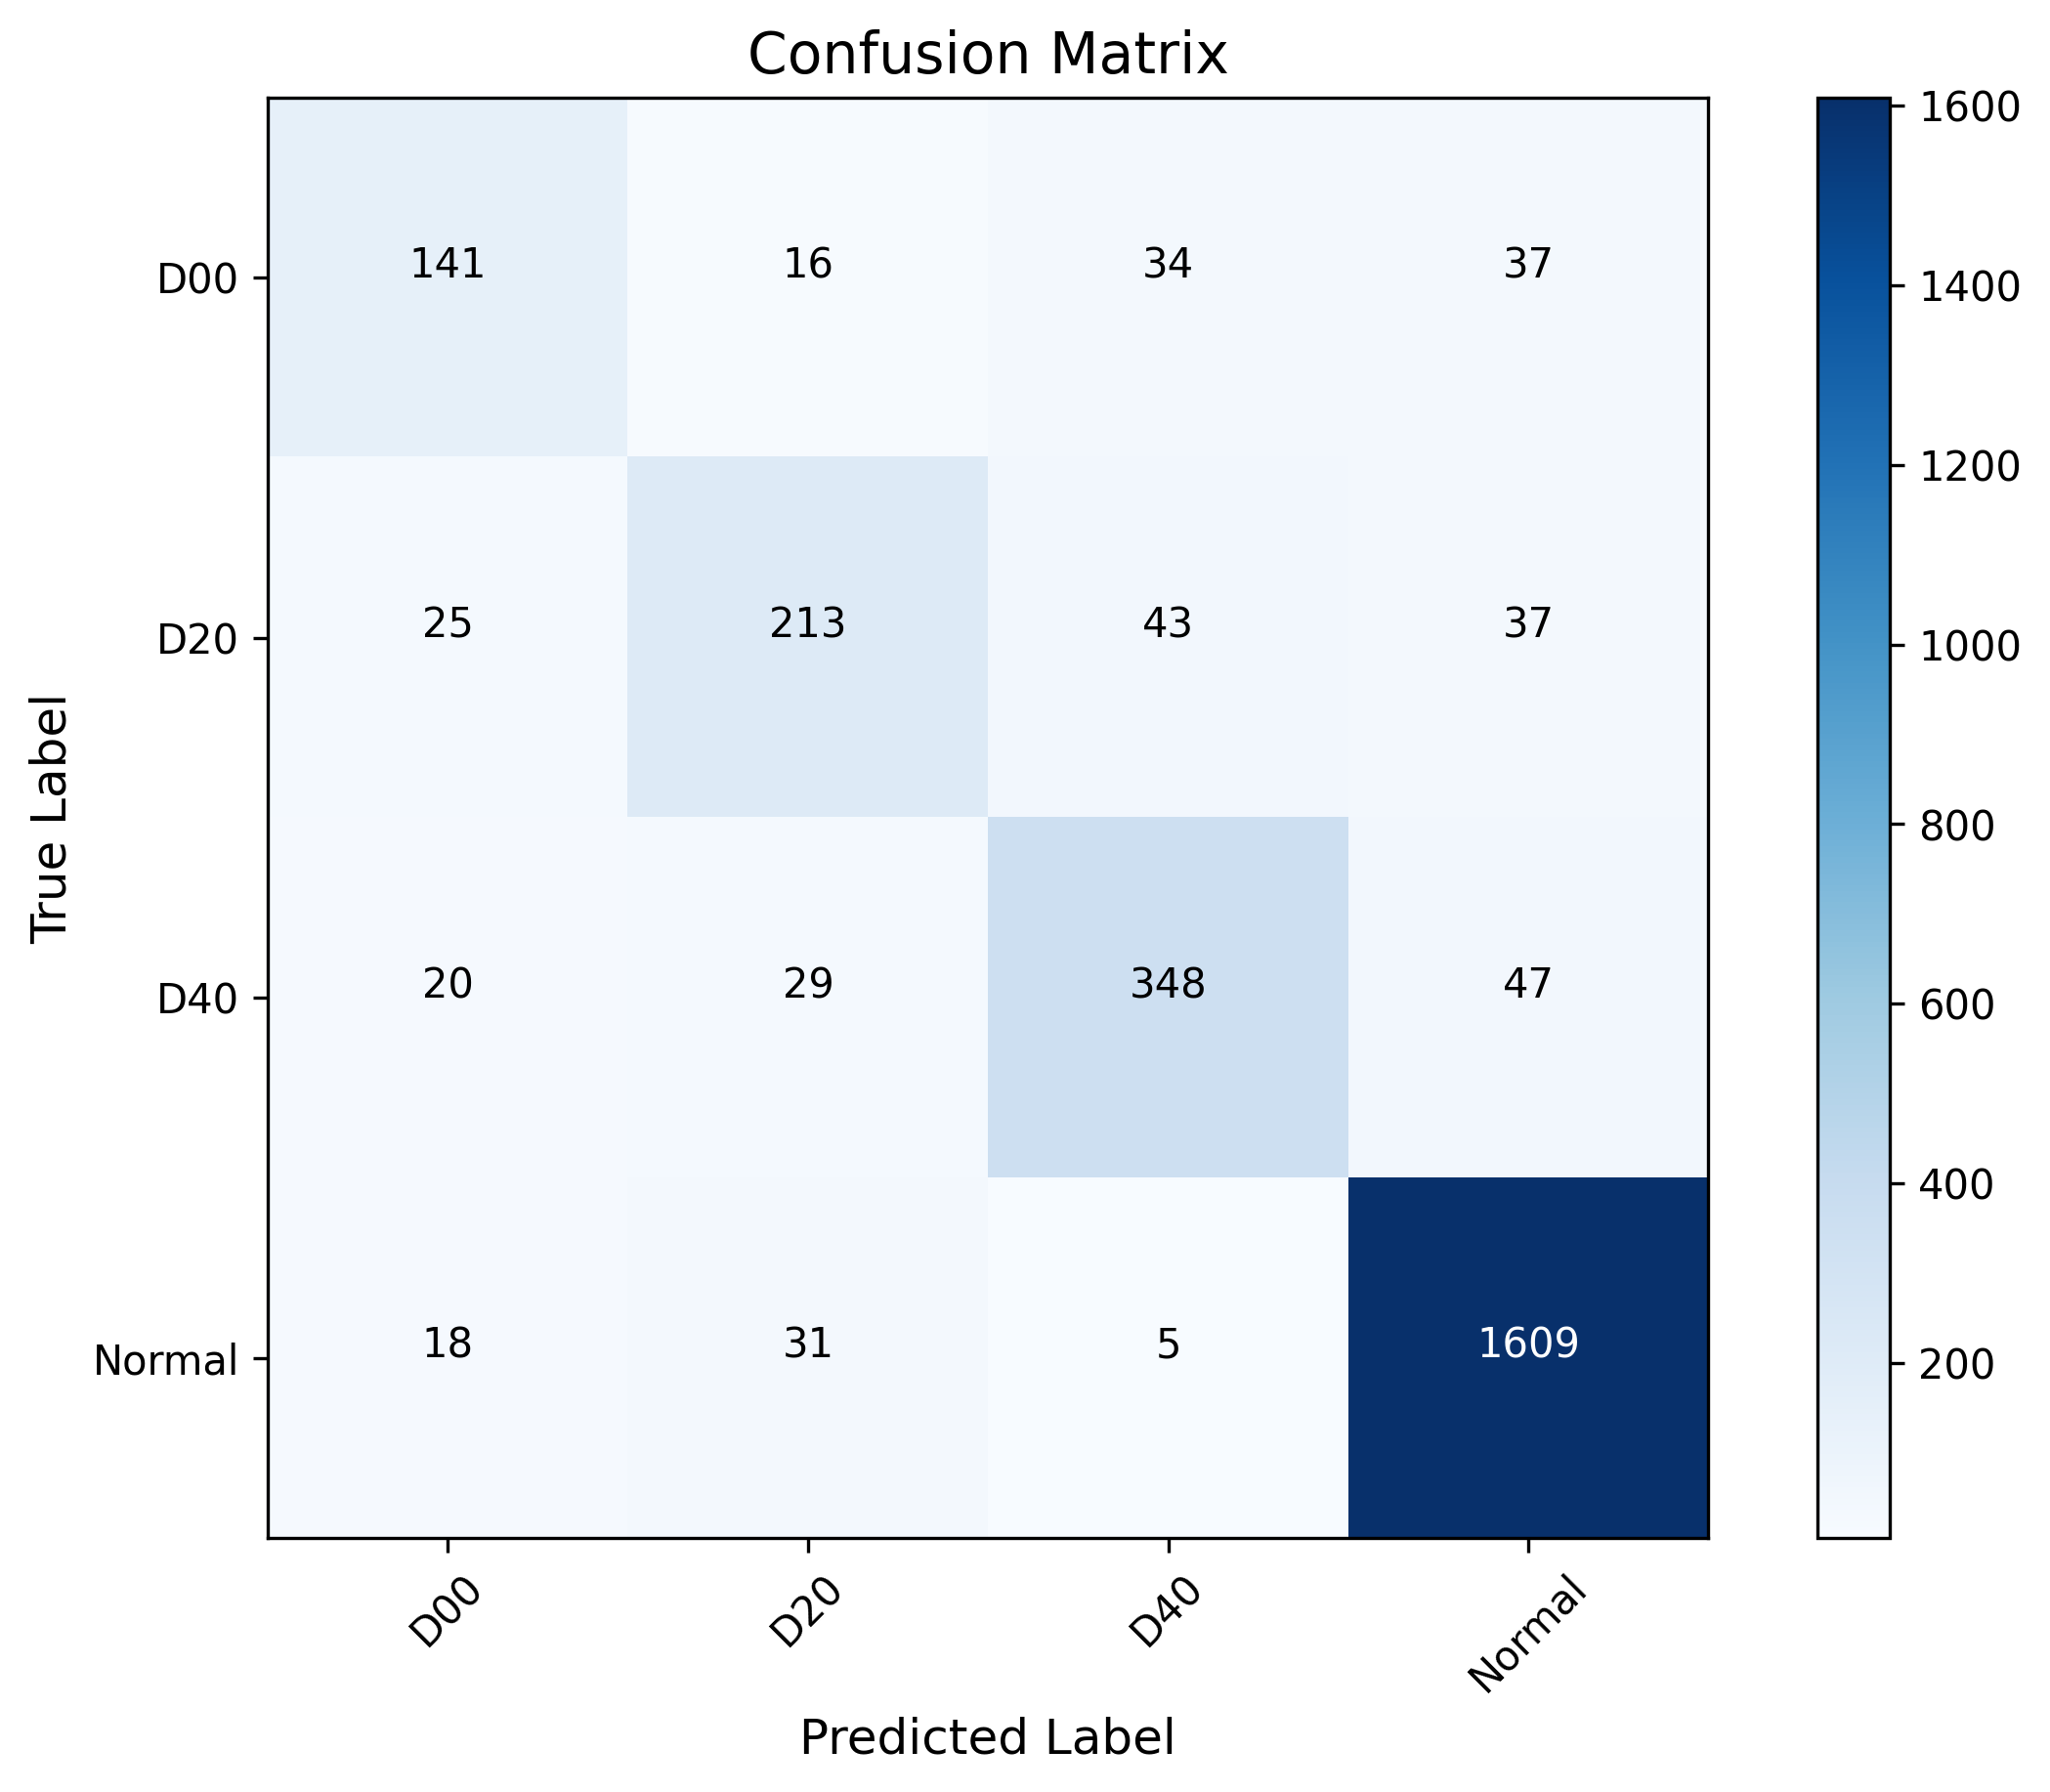

In [ ]:
# Mẹo: Ô này là code Python kết hợp bash để in luôn ảnh ra
%cd /content/image-preprocessing-classification
import os
from IPython.display import Image, display

print("\n" + "="*50)
print("⚙️ 1/2. ĐANG CHẠY PIPELINE 3 (SIÊU THAM SỐ GỐC)...")
!PYTHONPATH=. python src/data/preprocess_dataset.py --config configs/pipeline3_grayscale_bilateral.yaml
!PYTHONPATH=. python src/training/train.py --config configs/pipeline3_grayscale_bilateral.yaml

print("\n🎯 BẮT ĐẦU ĐÁNH GIÁ (GỐC)...")
!PYTHONPATH=. python src/evaluation/evaluate.py --config configs/pipeline3_grayscale_bilateral.yaml --model_path outputs/pipeline3_grayscale_bilateral/best_model.pth

img_path_goc = "/content/image-preprocessing-classification/outputs/pipeline3_grayscale_bilateral/confusion_matrix.png"
if os.path.exists(img_path_goc):
    print("\n📊 MA TRẬN NHẦM LẪN (GỐC):")
    display(Image(img_path_goc))

In [2]:
%%writefile configs/pipeline3_tuned.yaml
exp_name: "pipeline3_tuned"
data_dir: "data/processed"
output_dir: "outputs/pipeline3_tuned"
model_name: "resnet18"
pretrained: false
num_classes: 4
epochs: 30
batch_size: 64
learning_rate: 0.001
weight_decay: 0.0001
device: "cuda"
use_scheduler: true
scheduler_T_max: 30
scheduler_eta_min: 0.000001
early_stopping_patience: 5
image_size: 224
mean: [0.485, 0.456, 0.406]
std: [0.229, 0.224, 0.225]
preprocessing_mode: "grayscale_bilateral"
preprocessing_params:
  grayscale_bilateral:
    d: 5                       # ĐÃ ĐỔI: Giảm vùng lấy mẫu (gốc: 9)
    sigma_color: 20            # ĐÃ ĐỔI: Giảm làm mịn màu để giữ vết nứt (gốc: 75)
    sigma_space: 20            # ĐÃ ĐỔI: Giảm làm mịn không gian (gốc: 75)

Writing configs/pipeline3_tuned.yaml


/content/image-preprocessing-classification

🚀 2/2. ĐANG CHẠY PIPELINE 3 (CHỈ CHỈNH SỬA THAM SỐ GRAYSCALE & BILATERAL)...

--- Offline Preprocessing: pipeline3_tuned ---
Reorganizing raw cropped patches: moving train/val/test to data/processed/cropped
Reading raw cropped images from: data/processed/cropped
Saving preprocessed images to: data/processed/grayscale_bilateral
Processing split 'train', class 'D00' (1102 images)...
100% 1102/1102 [00:00<00:00, 1324.65it/s]
Processing split 'train', class 'D20' (1403 images)...
100% 1403/1403 [00:02<00:00, 601.06it/s]
Processing split 'train', class 'D40' (2278 images)...
100% 2278/2278 [00:01<00:00, 1386.26it/s]
Processing split 'train', class 'Normal' (7900 images)...
100% 7900/7900 [00:07<00:00, 1110.96it/s]
Processing split 'val', class 'D00' (225 images)...
100% 225/225 [00:00<00:00, 1312.49it/s]
Processing split 'val', class 'D20' (300 images)...
100% 300/300 [00:00<00:00, 605.94it/s]
Processing split 'val', class 'D40' (465 images)...
1

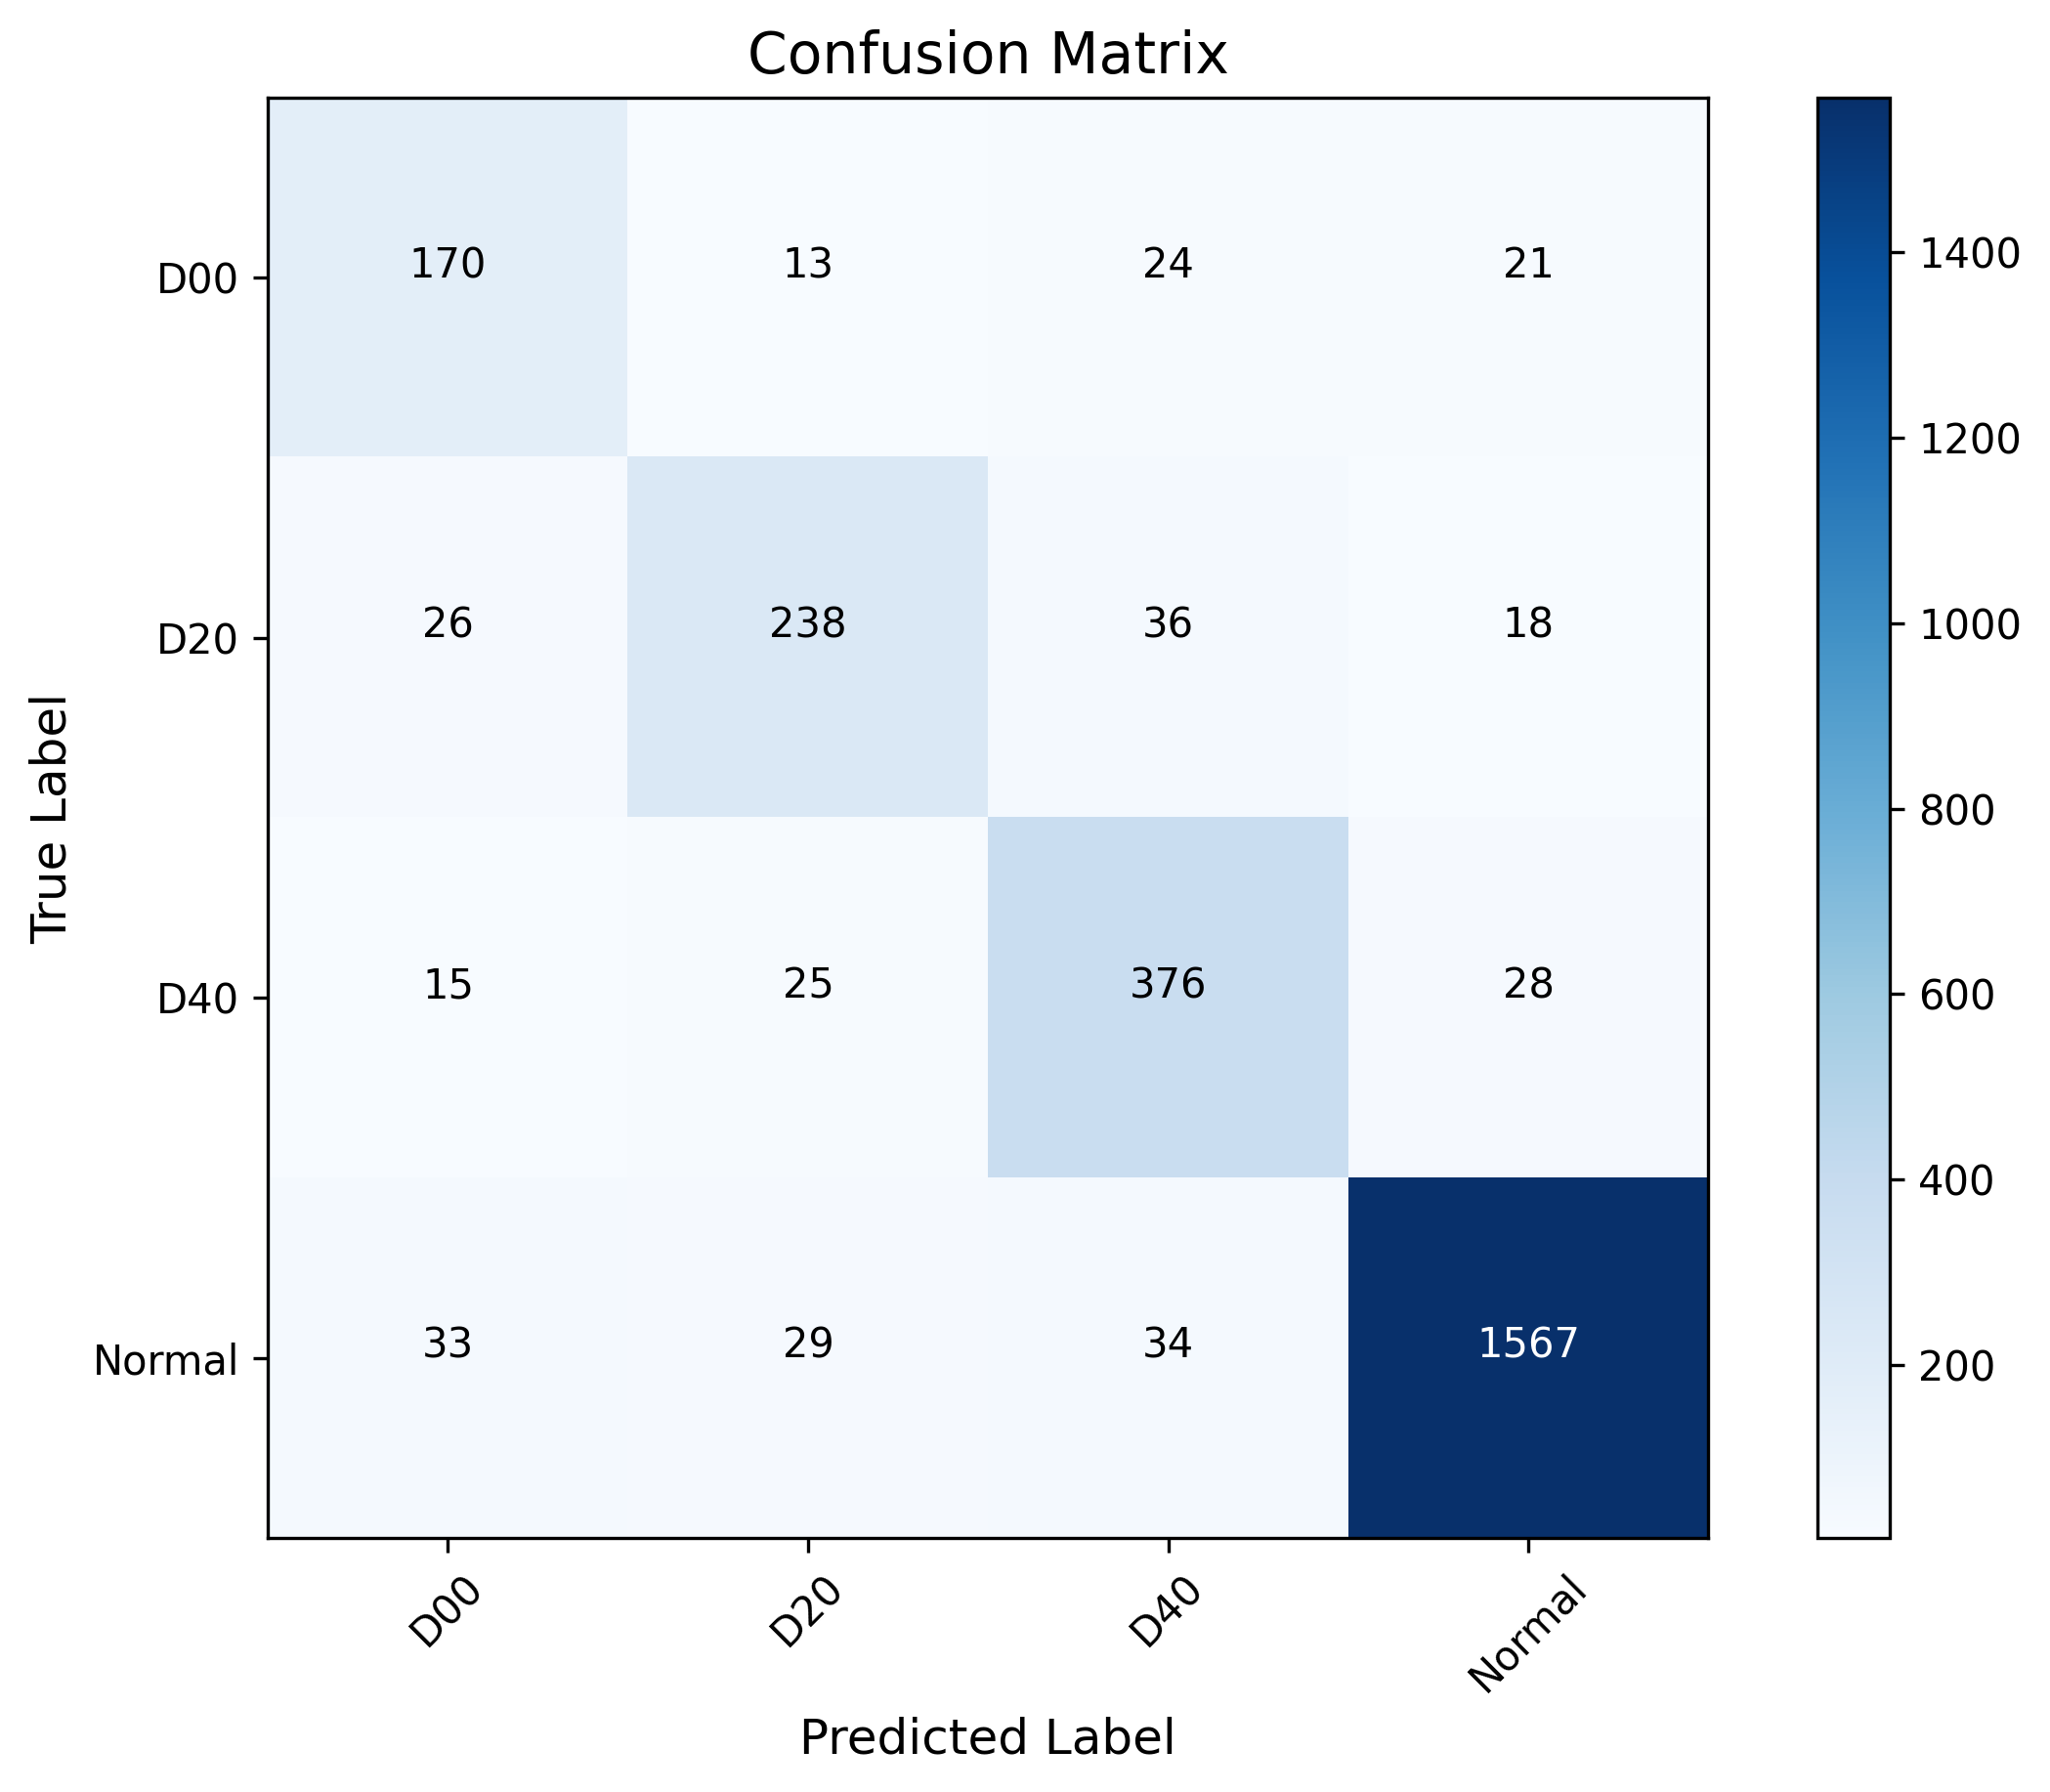

In [3]:
%cd /content/image-preprocessing-classification
import os
from IPython.display import Image, display

print("\n" + "="*50)
print("🚀 2/2. ĐANG CHẠY PIPELINE 3 (CHỈ CHỈNH SỬA THAM SỐ GRAYSCALE & BILATERAL)...")
!PYTHONPATH=. python src/data/preprocess_dataset.py --config configs/pipeline3_tuned.yaml
!PYTHONPATH=. python src/training/train.py --config configs/pipeline3_tuned.yaml

print("\n🎯 BẮT ĐẦU ĐÁNH GIÁ (THAM SỐ ĐÃ CHỈNH SỬA)...")
!PYTHONPATH=. python src/evaluation/evaluate.py --config configs/pipeline3_tuned.yaml --model_path outputs/pipeline3_tuned/best_model.pth

img_path_tuned = "/content/image-preprocessing-classification/outputs/pipeline3_tuned/confusion_matrix.png"
if os.path.exists(img_path_tuned):
    print("\n📊 MA TRẬN NHẦM LẪN (THAM SỐ GRAYSCALE & BILATERAL ĐÃ CHỈNH SỬA):")
    display(Image(img_path_tuned))
else:
    print(f"❌ Không tìm thấy ảnh. Vui lòng kiểm tra lại log train ở trên xem có lỗi không.")

Pipeline 4


/content/image-preprocessing-classification

⚙️ 1/2. ĐANG CHẠY PIPELINE 4 (GỐC - KẾT HỢP 3 KỸ THUẬT)...

--- Offline Preprocessing: pipeline4_combined ---
Reading raw cropped images from: data/processed/cropped
Saving preprocessed images to: data/processed/combined
Processing split 'train', class 'D00' (1102 images)...
100% 1102/1102 [00:03<00:00, 355.23it/s]
Processing split 'train', class 'D20' (1403 images)...
100% 1403/1403 [00:11<00:00, 125.39it/s]
Processing split 'train', class 'D40' (2278 images)...
100% 2278/2278 [00:05<00:00, 424.30it/s]
Processing split 'train', class 'Normal' (7900 images)...
100% 7900/7900 [00:22<00:00, 349.12it/s]
Processing split 'val', class 'D00' (225 images)...
100% 225/225 [00:00<00:00, 322.69it/s]
Processing split 'val', class 'D20' (300 images)...
100% 300/300 [00:02<00:00, 126.66it/s]
Processing split 'val', class 'D40' (465 images)...
100% 465/465 [00:01<00:00, 453.38it/s]
Processing split 'val', class 'Normal' (1671 images)...
100% 1671/1671 [00

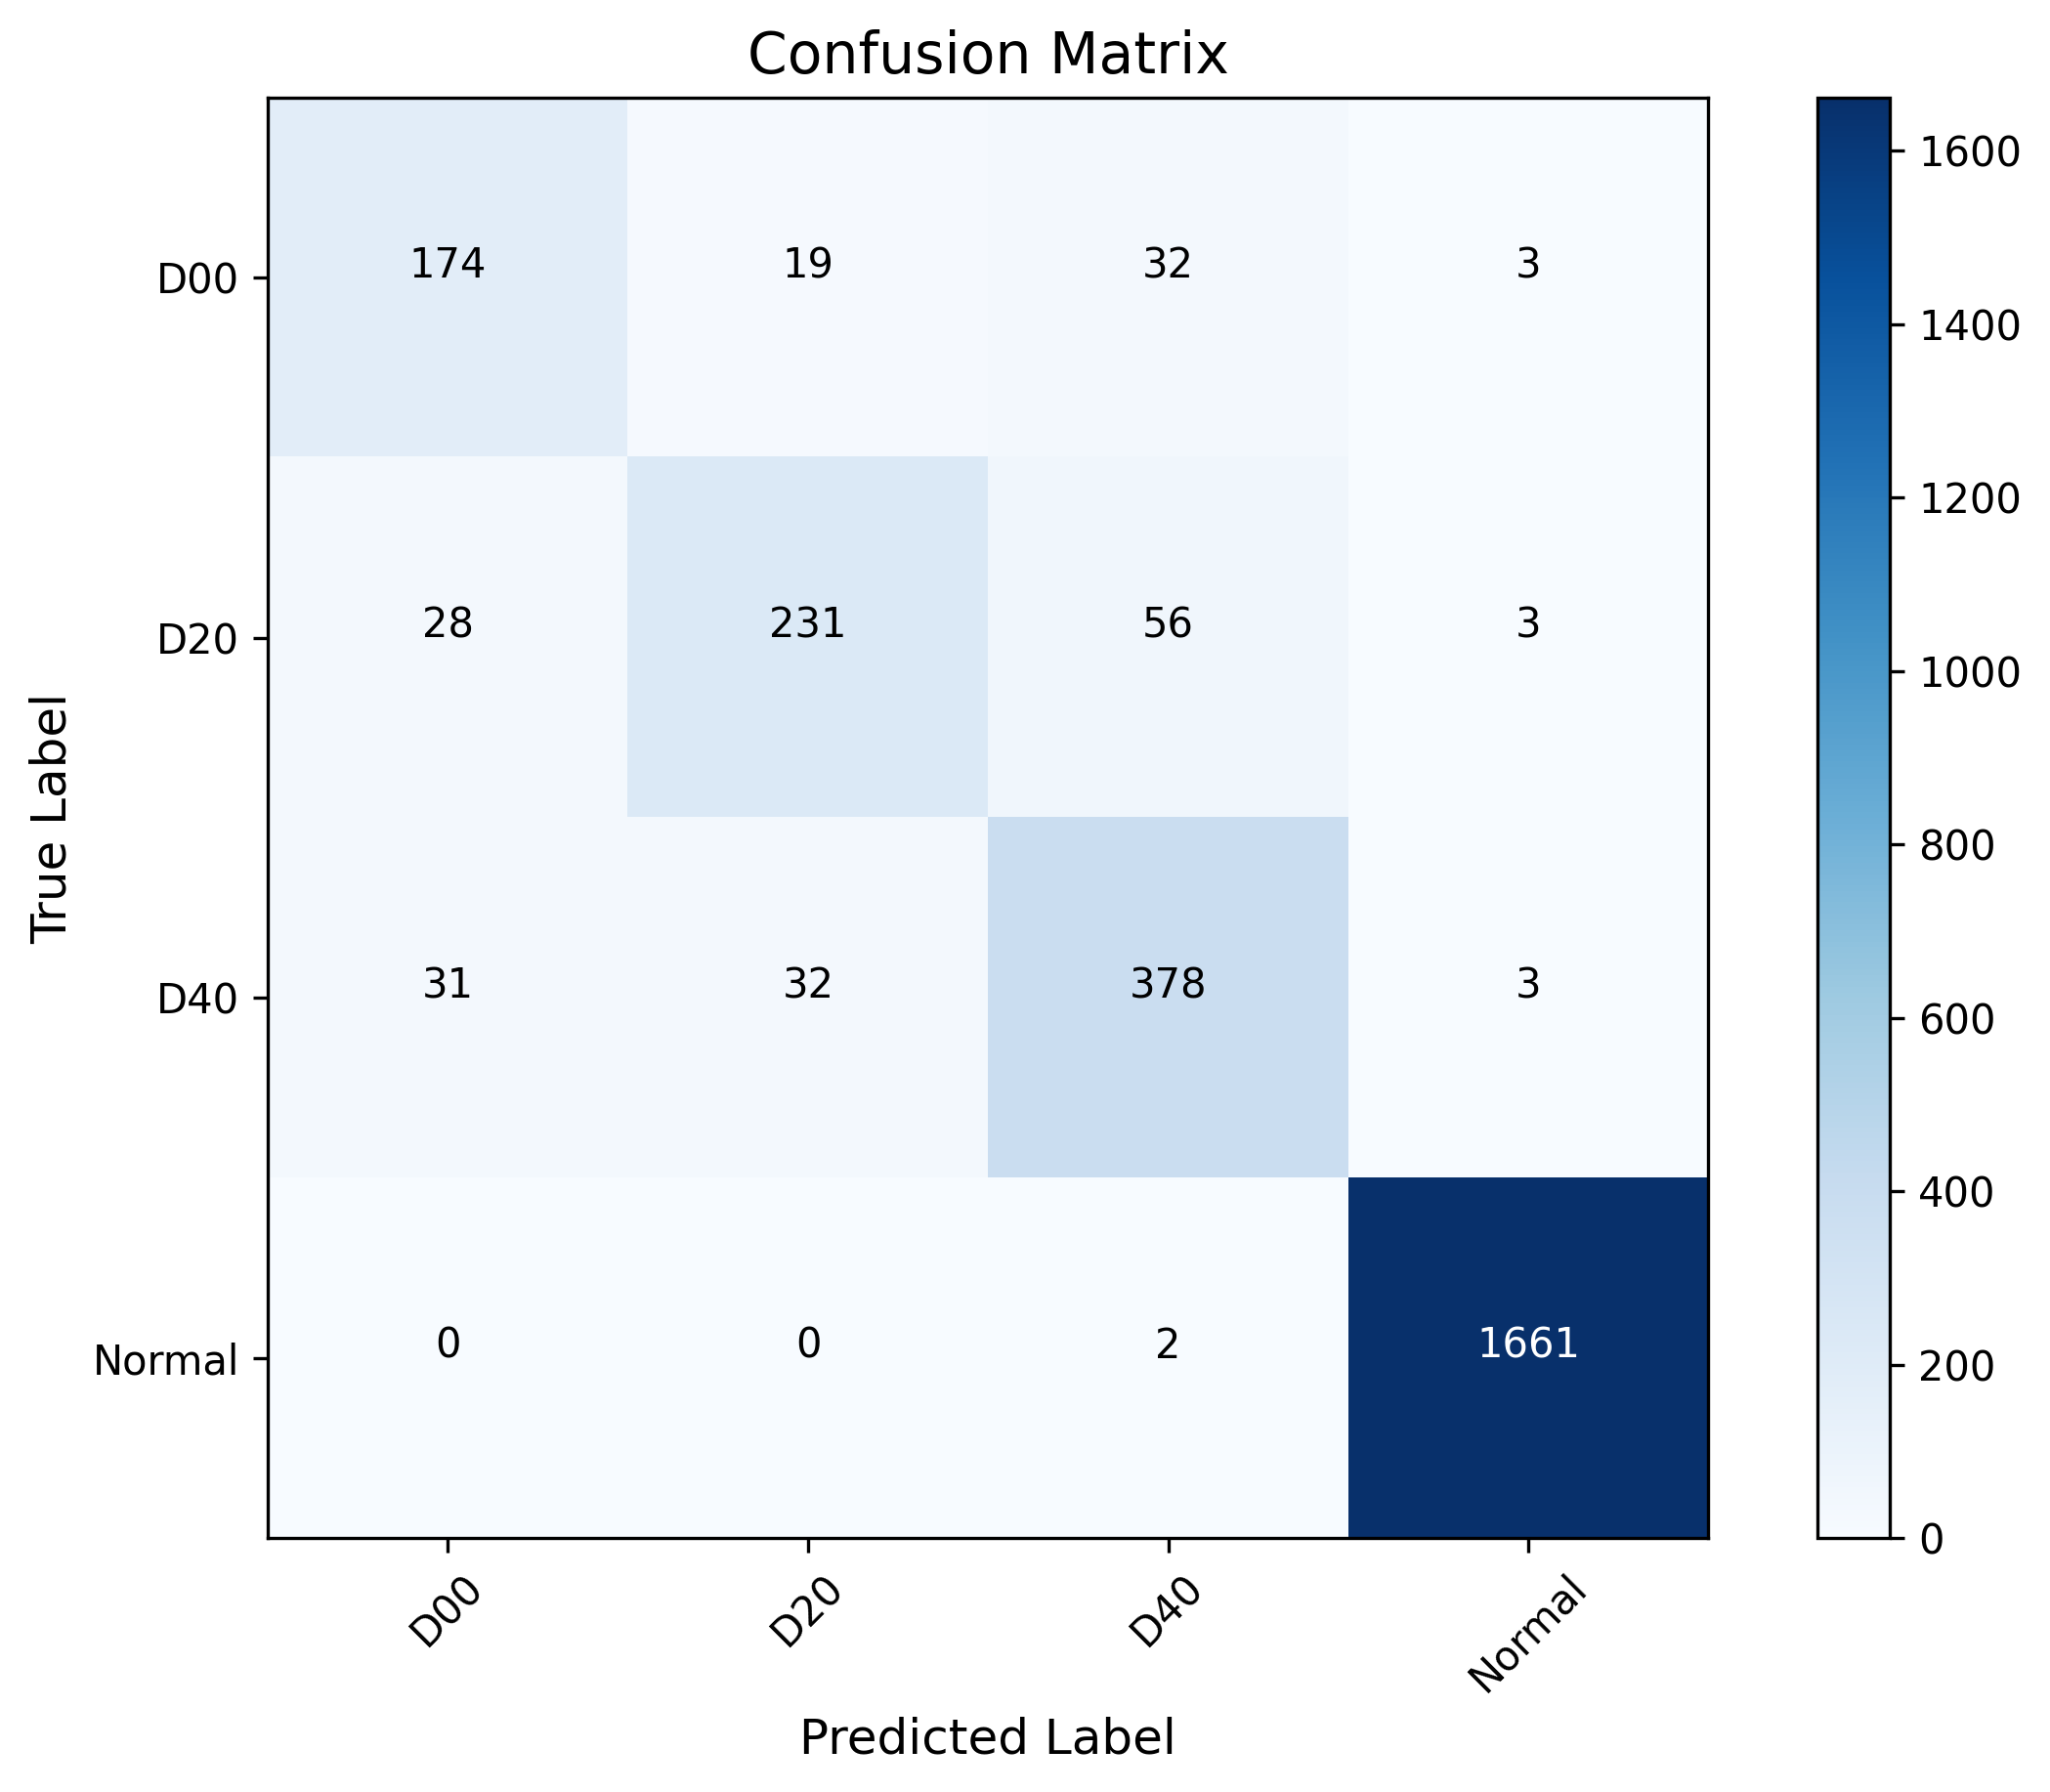

In [ ]:
# Đảm bảo đứng đúng thư mục dự án
%cd /content/image-preprocessing-classification
import os
from IPython.display import Image, display

print("\n" + "="*50)
print("⚙️ 1/2. ĐANG CHẠY PIPELINE 4 (GỐC - KẾT HỢP 3 KỸ THUẬT)...")
!PYTHONPATH=. python src/data/preprocess_dataset.py --config configs/pipeline4_combined.yaml
!PYTHONPATH=. python src/training/train.py --config configs/pipeline4_combined.yaml

print("\n🎯 BẮT ĐẦU ĐÁNH GIÁ (GỐC)...")
!PYTHONPATH=. python src/evaluation/evaluate.py --config configs/pipeline4_combined.yaml --model_path outputs/pipeline4_combined/best_model.pth

img_path_goc = "/content/image-preprocessing-classification/outputs/pipeline4_combined/confusion_matrix.png"
if os.path.exists(img_path_goc):
    print("\n📊 MA TRẬN NHẦM LẪN (PIPELINE 4 GỐC):")
    display(Image(img_path_goc))

In [4]:
%%writefile configs/pipeline4_tuned.yaml
exp_name: "pipeline4_tuned"
data_dir: "data/processed"
output_dir: "outputs/pipeline4_tuned"
model_name: "resnet18"
pretrained: false
num_classes: 4
epochs: 30
batch_size: 64
learning_rate: 0.001
weight_decay: 0.0001
device: "cuda"
use_scheduler: true
scheduler_T_max: 30
scheduler_eta_min: 0.000001
early_stopping_patience: 5
image_size: 224
mean: [0.485, 0.456, 0.406]
std: [0.229, 0.224, 0.225]
preprocessing_mode: "combined"
preprocessing_params:
  clahe:
    clip_limit: 2.0
    tile_grid_size: [8, 8]
  letterbox:
    border_mode: "constant"
    fill_value: [0, 0, 0]
  grayscale_bilateral:
    d: 5                       # ĐÃ ĐỔI: Giảm vùng lấy mẫu (gốc: 9)
    sigma_color: 20            # ĐÃ ĐỔI: Giảm làm mịn màu để giữ vết nứt (gốc: 75)
    sigma_space: 20            # ĐÃ ĐỔI: Giảm làm mịn không gian (gốc: 75)

Writing configs/pipeline4_tuned.yaml


/content/image-preprocessing-classification

🚀 2/2. ĐANG CHẠY PIPELINE 4 (CHỈ CHỈNH SỬA THAM SỐ GRAYSCALE & BILATERAL)...

--- Offline Preprocessing: pipeline4_tuned ---
Reading raw cropped images from: data/processed/cropped
Saving preprocessed images to: data/processed/combined
Processing split 'train', class 'D00' (1102 images)...
100% 1102/1102 [00:03<00:00, 286.17it/s]
Processing split 'train', class 'D20' (1403 images)...
100% 1403/1403 [00:05<00:00, 247.42it/s]
Processing split 'train', class 'D40' (2278 images)...
100% 2278/2278 [00:03<00:00, 659.96it/s]
Processing split 'train', class 'Normal' (7900 images)...
100% 7900/7900 [00:14<00:00, 561.98it/s]
Processing split 'val', class 'D00' (225 images)...
100% 225/225 [00:00<00:00, 502.00it/s]
Processing split 'val', class 'D20' (300 images)...
100% 300/300 [00:01<00:00, 232.72it/s]
Processing split 'val', class 'D40' (465 images)...
100% 465/465 [00:00<00:00, 748.28it/s]
Processing split 'val', class 'Normal' (1671 images)...
100

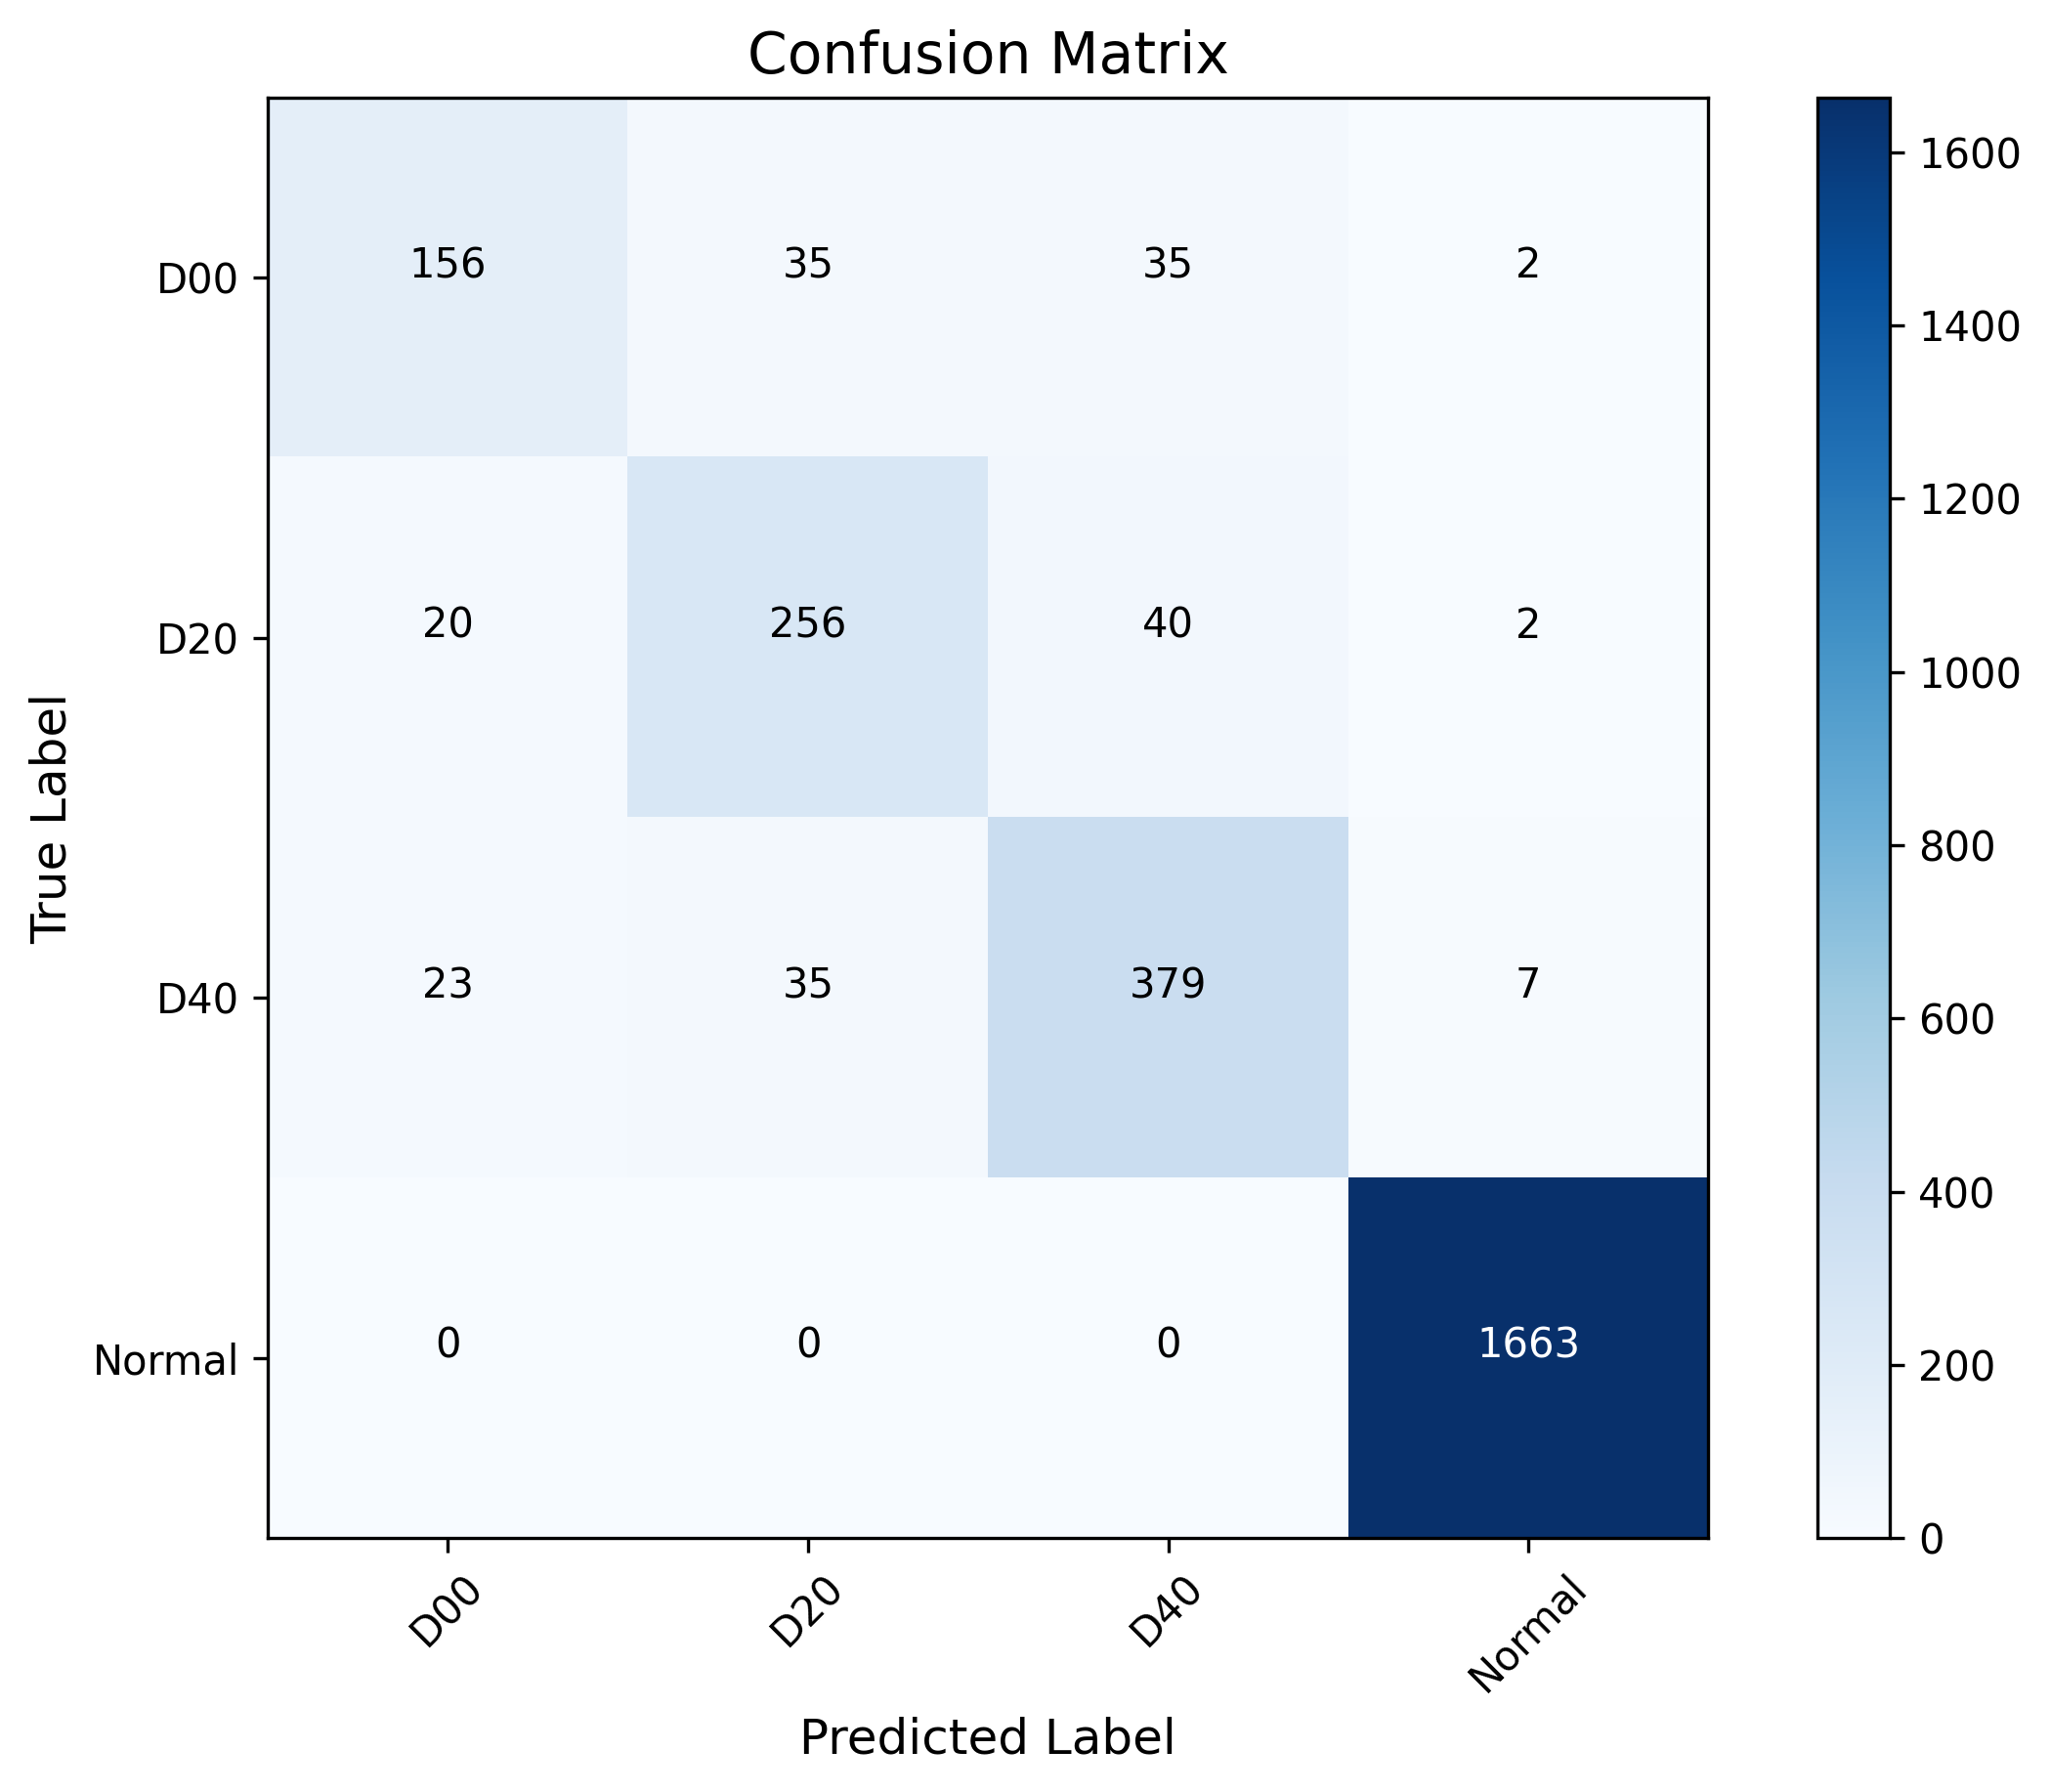

In [5]:
%cd /content/image-preprocessing-classification
import os
from IPython.display import Image, display

print("\n" + "="*50)
print("🚀 2/2. ĐANG CHẠY PIPELINE 4 (CHỈ CHỈNH SỬA THAM SỐ GRAYSCALE & BILATERAL)...")
!PYTHONPATH=. python src/data/preprocess_dataset.py --config configs/pipeline4_tuned.yaml
!PYTHONPATH=. python src/training/train.py --config configs/pipeline4_tuned.yaml

print("\n🎯 BẮT ĐẦU ĐÁNH GIÁ (THAM SỐ ĐÃ CHỈNH SỬA)...")
!PYTHONPATH=. python src/evaluation/evaluate.py --config configs/pipeline4_tuned.yaml --model_path outputs/pipeline4_tuned/best_model.pth

img_path_tuned = "/content/image-preprocessing-classification/outputs/pipeline4_tuned/confusion_matrix.png"
if os.path.exists(img_path_tuned):
    print("\n📊 MA TRẬN NHẦM LẪN (PIPELINE 4 - THAM SỐ ĐÃ CHỈNH SỬA):")
    display(Image(img_path_tuned))
else:
    print(f"❌ Không tìm thấy ảnh. Vui lòng kiểm tra lại log train ở trên xem có lỗi không.")

In [6]:
from google.colab import files
import os

# Nén kết quả pipeline 3 và pipeline 4 đã chỉnh tham số vào 1 file zip
!zip -r outputs_tuned_p3_p4.zip outputs/pipeline3_tuned/ outputs/pipeline4_tuned/

# Tải về máy
print("📦 Đang tải file kết quả về máy...")
files.download('/content/image-preprocessing-classification/outputs_tuned_p3_p4.zip')
print("✅ Tải xong! Kiểm tra thư mục Downloads trên máy tính của bạn nhé!")

  adding: outputs/pipeline3_tuned/ (stored 0%)
  adding: outputs/pipeline3_tuned/confusion_matrix.png (deflated 21%)
  adding: outputs/pipeline3_tuned/history.json (deflated 66%)
  adding: outputs/pipeline3_tuned/test_evaluation.json (deflated 71%)
  adding: outputs/pipeline3_tuned/best_model.pth (deflated 6%)
  adding: outputs/pipeline4_tuned/ (stored 0%)
  adding: outputs/pipeline4_tuned/confusion_matrix.png (deflated 21%)
  adding: outputs/pipeline4_tuned/history.json (deflated 63%)
  adding: outputs/pipeline4_tuned/test_evaluation.json (deflated 70%)
  adding: outputs/pipeline4_tuned/best_model.pth (deflated 7%)
📦 Đang tải file kết quả về máy...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Tải xong! Kiểm tra thư mục Downloads trên máy tính của bạn nhé!
